## Clustering: The Art of Grouping Data 📦

**Clustering is an unsupervised machine learning task** that involves grouping a set of data points in such a way that data points in the same group (cluster) are more similar to each other than to those in other groups. Unlike supervised learning, where you have predefined categories (labels), in clustering, the algorithm discovers these groups based on the intrinsic structure of the data itself. There's no "correct" answer given beforehand; the algorithm finds patterns of similarity.

**Analogy:** Imagine you're given a mixed basket of fruits, but you don't know their names. Clustering is like sorting these fruits into piles based on visible characteristics like color, size, and shape. You might end up with a pile of red, round things (apples, tomatoes), a pile of yellow, elongated things (bananas, lemons), and so on. The clusters are the piles you've created, and the "similarity" is how alike the fruits within each pile are.




### Why is Clustering Useful?

  * **Customer Segmentation:** Grouping customers with similar buying behaviors for targeted marketing.
  * **Document Analysis:** Organizing large collections of text documents into topics.
  * **Image Segmentation:** Dividing an image into regions of similar pixels.
  * **Anomaly Detection:** Identifying outliers or unusual data points that don't fit into any cluster.
  * **Genomic Analysis:** Grouping genes with similar expression patterns.

-----

## 1\. K-Means Clustering

**K-Means** is a popular and relatively simple partitioning clustering algorithm. Its goal is to partition 'n' observations into 'k' clusters, where each observation belongs to the cluster with the nearest mean (centroid). You **must specify the number of clusters, 'k',** before running the algorithm.



### How it Works (Iterative Process):

1.  **Initialization:**
      * Randomly select 'k' data points from your dataset. These become the initial **centroids** (the center points of your clusters).
2.  **Assignment Step (Expectation):**
      * For each data point in the dataset, calculate its **distance** (e.g., Euclidean distance) to all 'k' centroids.
      * Assign the data point to the cluster whose centroid is **closest**.
3.  **Update Step (Maximization):**
      * After all data points have been assigned to clusters, **recalculate the new centroid** for each cluster. This new centroid is simply the **mean** of all data points currently assigned to that cluster.
4.  **Repeat:**
      * Steps 2 and 3 are repeated until either:
          * The cluster assignments no longer change.
          * The centroids no longer move significantly.
          * A maximum number of iterations is reached.

The algorithm aims to minimize the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**. This is the sum of squared distances between each data point and the centroid of its assigned cluster. A lower WCSS generally indicates better clustering, as it means data points are closer to their respective cluster centers.



### Choosing the Optimal 'k': The Elbow Method

Since you need to choose 'k' beforehand, the **Elbow Method** is a common heuristic. You run K-Means for a range of 'k' values (e.g., 1 to 10) and calculate the WCSS for each 'k'. Then, you plot WCSS against 'k'. The "elbow" point in the graph, where the rate of decrease in WCSS significantly slows down, is often considered the optimal 'k'.

### K-Means Code Example

**1. Generate Sample Data**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs # For generating synthetic data
from sklearn.metrics import silhouette_score # For evaluating clusters

# We'll create a dataset with clear clusters to easily visualize K-Means
n_samples = 300
random_state = 42
X, y_true = make_blobs(n_samples=n_samples, centers=4, cluster_std=0.60, random_state=random_state)
# X: The feature data (what we'll cluster)
# y_true: The true labels (we'll use this only for comparison/visualization, K-Means doesn't use it)

print("Shape of generated data (X):", X.shape)
print("First 5 data points:\n", X[:5])

Shape of generated data (X): (300, 2)
First 5 data points:
 [[ -9.1139443    6.81361629]
 [ -9.35457578   7.09278959]
 [ -2.01567068   8.28177994]
 [ -7.01023591  -6.22084348]
 [-10.06120248   6.71867113]]


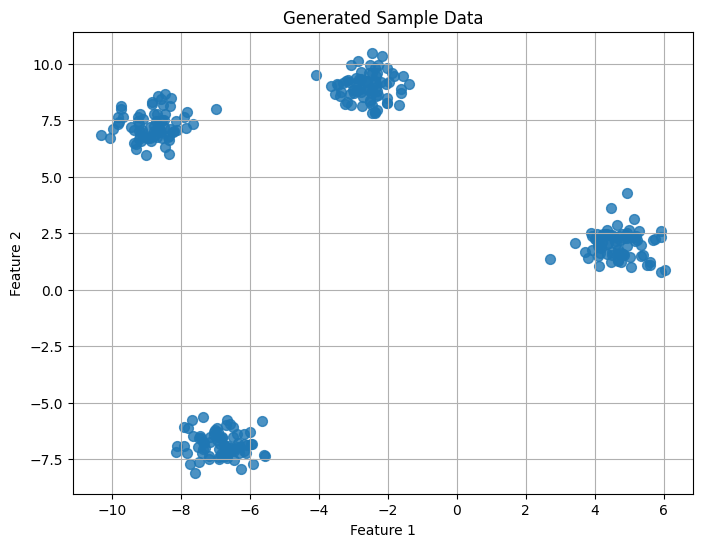

In [ ]:
# Visualize the generated data before clustering
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.8)
plt.title('Generated Sample Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

**2.Apply K-Means Clustering**

In [ ]:
# Let's assume we want to find 4 clusters (ideal scenario for this data)
k_means_model = KMeans(n_clusters=4, random_state=random_state, n_init='auto') # n_init='auto' is default for newer sklearn
k_means_model.fit(X)

# Get the cluster labels assigned to each data point
labels = k_means_model.labels_
print("\nFirst 10 cluster assignments (labels):", labels[:10])

# Get the coordinates of the final cluster centroids
centroids = k_means_model.cluster_centers_
print("\nCluster Centroids:\n", centroids)


First 10 cluster assignments (labels): [3 3 0 1 3 1 2 1 0 2]

Cluster Centroids:
 [[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]


**3. Visualize K-Means Results**

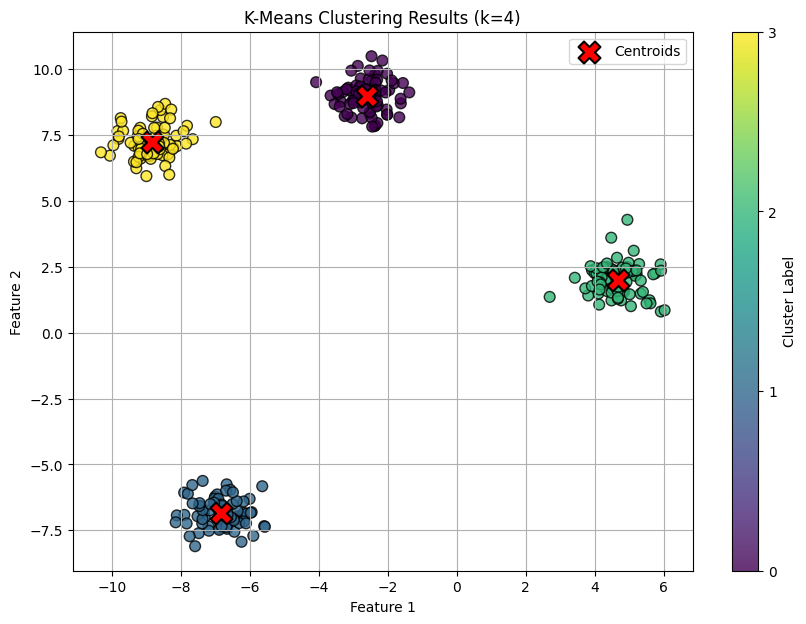

In [ ]:
plt.figure(figsize=(10, 7))
# Plot the data points, colored by their assigned cluster
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', s=60, alpha=0.8, edgecolor='k')
# Plot the cluster centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=250, label='Centroids', edgecolor='black', linewidth=1.5)
plt.title('K-Means Clustering Results (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.colorbar(scatter, ticks=range(4), label='Cluster Label')
plt.show()

**4. The Elbow Method to Find Optimal 'k'**

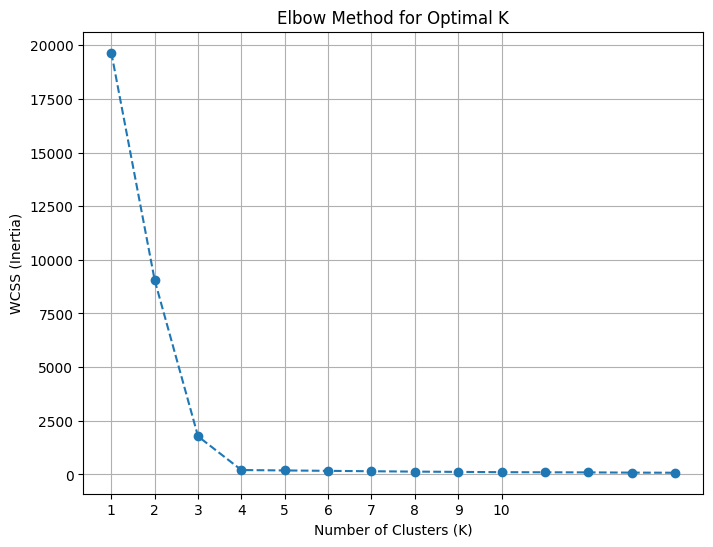

In [ ]:
# How to choose 'k'? The Elbow Method
# Calculate WCSS for different values of k
from sklearn.metrics import silhouette_score
wcss = []
silhoutte_scores = []
for i in range(1, 15): # Try k from 1 to 10
    kmeans_elbow = KMeans(n_clusters=i, random_state=random_state, n_init='auto')
    kmeans_elbow.fit(X)
    labels_elbow = kmeans_elbow.predict(X)
    if len(np.unique(labels_elbow)) > 1: # Silhouette score needs at least 2 clusters
      silhoutte_scores.append(round(silhouette_score(X, labels_elbow), 3))
    else:
      silhoutte_scores.append(round(0, 3))

    wcss.append(round(kmeans_elbow.inertia_,3)) # inertia_ is the WCSS

plt.figure(figsize=(8, 6))
plt.plot(range(1, 15), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


**Optional: Silhouette Score for Cluster Evaluation**

In [ ]:
# The silhouette score ranges from -1 to 1.
# Closer to 1: Data point is well-matched to its own cluster and poorly matched to neighboring clusters.
# Around 0: Data point is on or very close to the decision boundary between two neighboring clusters.
# Closer to -1: Data point is probably assigned to the wrong cluster.

# Calculate silhouette score for k=4 (our chosen k)
if len(np.unique(labels)) > 1: # Silhouette score needs at least 2 clusters
    silhouette_avg = silhouette_score(X, labels)
    print(f"\nSilhouette Score for K=4: {silhouette_avg:.3f}")
else:
    print("\nSilhouette score cannot be computed for a single cluster (K=1).")


Silhouette Score for K=4: 0.876


In [ ]:
import warnings
import pandas as pd

# Suppress FutureWarning messages globally
warnings.simplefilter(action='ignore', category=FutureWarning)

add_to_list = []
df = pd.DataFrame(columns=['K', 'WCSS', 'Silhouette'])
for i, value in enumerate(wcss):
  add_to_list.append({'K': i+1, 'WCSS': value, 'Silhouette': silhoutte_scores[i]})

df = pd.concat([df, pd.DataFrame(add_to_list)], ignore_index=True)
print("Look for the 'elbow' point where the decrease in WCSS slows down significantly.")
df

Look for the 'elbow' point where the decrease in WCSS slows down significantly.


,K,WCSS,Silhouette
0,1,19652.395,0.000
1,2,9051.816,0.615
2,3,1773.737,0.799
3,4,203.891,0.876
4,5,185.213,0.731
5,6,166.735,0.585
6,7,148.257,0.452
7,8,130.898,0.330
8,9,117.922,0.338
9,10,104.542,0.359


-----

## 2\. Hierarchical Clustering

**Hierarchical Clustering** (also known as Hierarchical Cluster Analysis or HCA) builds a hierarchy of clusters, represented as a tree-like diagram called a **dendrogram**. It doesn't require you to specify the number of clusters beforehand; instead, you decide the number of clusters by cutting the dendrogram at an appropriate level.

There are two main approaches:

1.  **Agglomerative (Bottom-Up) Clustering:**

      * Starts with **each data point as its own individual cluster**.
      * In each step, it **merges the two closest (most similar) clusters** until only one large cluster (containing all data points) remains.
      * This is the more common type.

2.  **Divisive (Top-Down) Clustering:**

      * Starts with **all data points in one single cluster**.
      * In each step, it **splits the most heterogeneous (dissimilar) cluster** into two smaller clusters until each data point is its own cluster.

### Key Concepts in Agglomerative Clustering:

  * **Proximity/Distance Measure:** How the similarity/dissimilarity between individual data points is calculated (e.g., Euclidean, Manhattan, Cosine distance).
  * **Linkage Criterion:** How the distance between **clusters** (which can contain multiple points) is calculated. Common types:
      * **Ward's Linkage:** Minimizes the variance within each cluster. Tends to produce more compact, spherical clusters. *Often a good default choice.*
      * **Single Linkage:** The distance between two clusters is the minimum distance between any single data point in the first cluster and any single data point in the second. Can lead to "chaining" effects.
      * **Complete Linkage:** The distance between two clusters is the maximum distance between any single data point in the first cluster and any single data point in the second. Tends to produce more compact clusters.
      * **Average Linkage:** The distance between two clusters is the average distance between all data points in the first cluster and all data points in the second.

### The Dendrogram: Visualizing the Hierarchy

A **dendrogram** is a tree diagram that illustrates the hierarchical relationships between clusters.

  * The **leaves** of the dendrogram represent individual data points.
  * The **branches** represent mergers (in agglomerative) or splits (in divisive).
  * The **height** of the merger point on the y-axis indicates the distance at which two clusters were merged. Taller lines mean clusters were merged at greater distances (less similar).
  * To determine the number of clusters, you draw a horizontal line across the dendrogram. The number of vertical lines it crosses indicates the number of clusters. You typically look for a height where a large vertical distance is crossed by your line without crossing many horizontal lines below it, indicating distinct clusters.


### When to Use:

  * When the number of clusters is not known beforehand and you want to explore different granularity levels.
  * When you want to visualize the relationships between data points and clusters (dendrogram).
  * For small to medium-sized datasets, as it can be computationally intensive for very large datasets.


### Hierarchical Clustering Code Example

**1. Generate Sample Data**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage # For dendrogram visualization
from sklearn.metrics import silhouette_score # For evaluating clusters

# Using the same data as K-Means for consistency
n_samples = 300
random_state = 42
X, y_true = make_blobs(n_samples=n_samples, centers=4, cluster_std=0.60, random_state=random_state)

print("Shape of generated data (X):", X.shape)
print("First 5 data points:\n", X[:5])


Shape of generated data (X): (300, 2)
First 5 data points:
 [[ -9.1139443    6.81361629]
 [ -9.35457578   7.09278959]
 [ -2.01567068   8.28177994]
 [ -7.01023591  -6.22084348]
 [-10.06120248   6.71867113]]


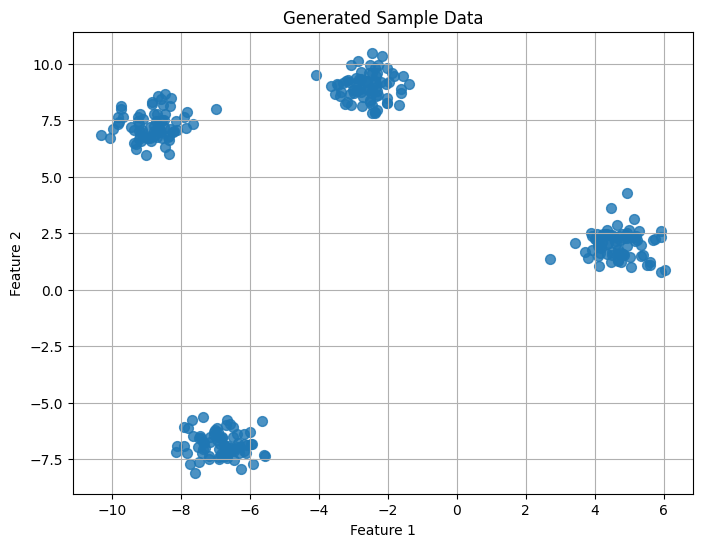

In [ ]:
# Visualize the generated data before clustering
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.8)
plt.title('Generated Sample Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

**2. Perform Agglomerative Hierarchical Clustering**

In [ ]:
# We'll use Ward linkage, which is generally a good choice for compactness
# n_clusters=None for now, we'll let it build the full hierarchy for the dendrogram
# Then we'll re-run with a chosen number of clusters based on the dendrogram.
agg_model_full = AgglomerativeClustering(linkage='ward')
agg_model_full.fit(X)

AgglomerativeClustering()

**3. Visualize the Dendrogram**

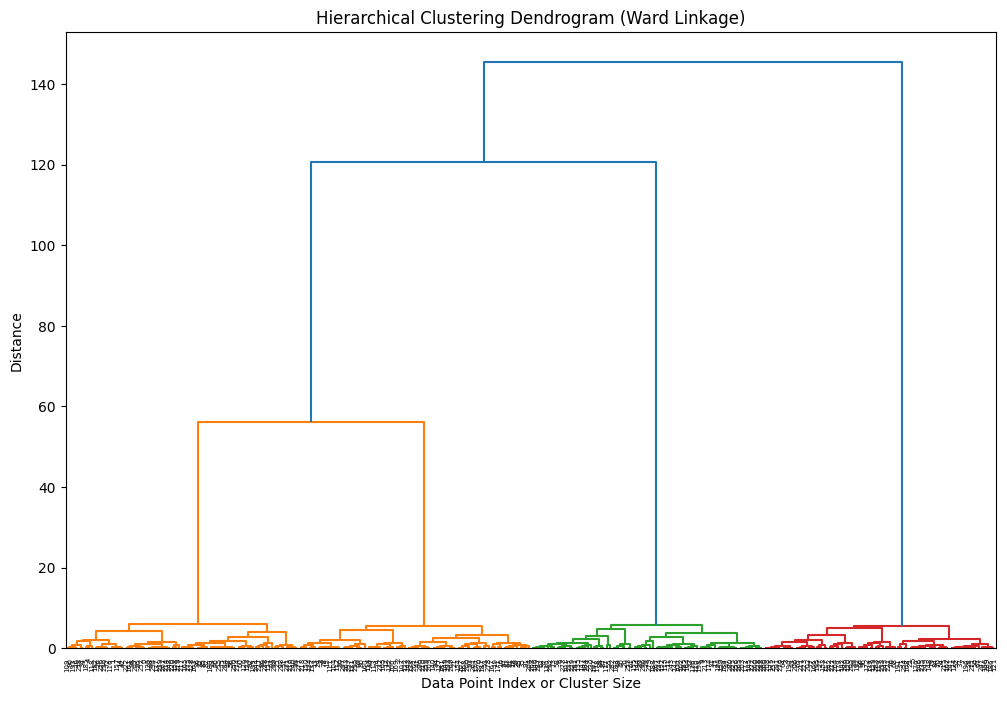


Observe the dendrogram: A long vertical line suggests distinct clusters.
To determine the number of clusters, draw a horizontal line where a large distance is crossed.
For this data, cutting at a distance around 5-7 would result in 4 clusters.


In [ ]:
# Calculate the linkage matrix for the dendrogram
# 'linkage' function takes the data and linkage method to compute the hierarchy
linked_data = linkage(X, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False) # Set to True to show count of original observations in each leaf
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Data Point Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

print("\nObserve the dendrogram: A long vertical line suggests distinct clusters.")
print("To determine the number of clusters, draw a horizontal line where a large distance is crossed.")
print("For this data, cutting at a distance around 5-7 would result in 4 clusters.")


**4. Re-run Agglomerative Clustering with a chosen number of clusters**

In [ ]:
# Based on the dendrogram, let's confirm 4 clusters
n_clusters_chosen = 4
agg_model_final = AgglomerativeClustering(n_clusters=n_clusters_chosen, linkage='ward')
final_labels = agg_model_final.fit_predict(X) # fit_predict directly returns labels

print(f"\nFirst 10 cluster assignments (labels) with {n_clusters_chosen} clusters:", final_labels[:10])



First 10 cluster assignments (labels) with 4 clusters: [0 0 3 1 0 1 2 1 3 2]


**5. Visualize Hierarchical Clustering Results**

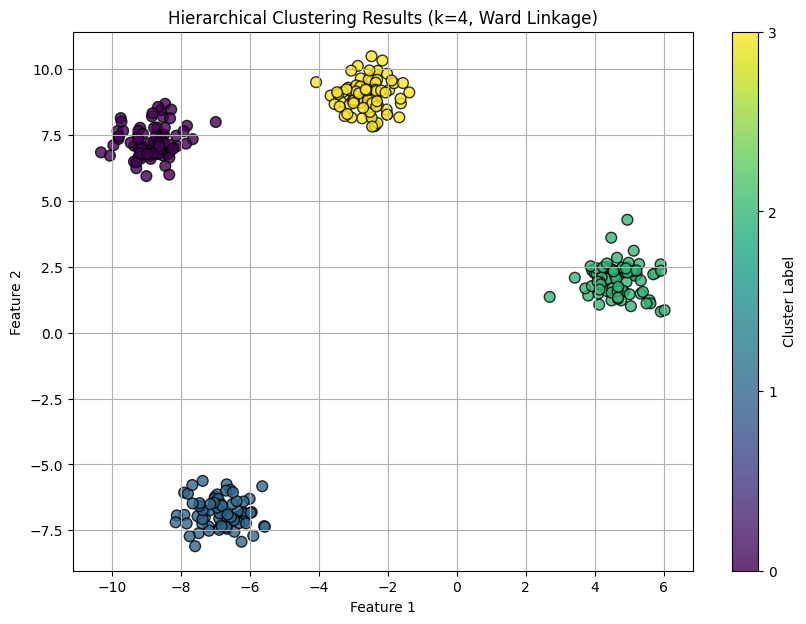


Silhouette Score for Hierarchical Clustering (k=4): 0.876


In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis', marker='o', s=60, alpha=0.8, edgecolor='k')
plt.title(f'Hierarchical Clustering Results (k={n_clusters_chosen}, Ward Linkage)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.colorbar(scatter, ticks=range(n_clusters_chosen), label='Cluster Label')
plt.show()

# --- Optional: Silhouette Score for Cluster Evaluation ---
if len(np.unique(final_labels)) > 1: # Silhouette score needs at least 2 clusters
    silhouette_avg_agg = silhouette_score(X, final_labels)
    print(f"\nSilhouette Score for Hierarchical Clustering (k={n_clusters_chosen}): {silhouette_avg_agg:.3f}")
else:
    print("\nSilhouette score cannot be computed for a single cluster.")

-----

## K-Means vs. Hierarchical Clustering: A Quick Comparison

| Feature            | K-Means Clustering                                     | Hierarchical Clustering                              |
| :----------------- | :----------------------------------------------------- | :--------------------------------------------------- |
| **Cluster Shape** | Assumes spherical clusters.                           | Can find clusters of various shapes (especially with single/complete linkage). |
| **'k' Value** | **Requires 'k' (number of clusters) as input.** | Does not require 'k' beforehand; determined by cutting dendrogram. |
| **Output** | Flat partitioning of data points into 'k' clusters.  | A hierarchy of clusters (dendrogram).                |
| **Computational Cost** | Faster, especially for large datasets.              | Slower, $O(n^3)$ or $O(n^2)$ for some methods, can be an issue for very large datasets. |
| **Sensitivity to Outliers** | Sensitive to outliers, as they can pull centroids. | Less sensitive, especially with certain linkage methods. |
| **Interpretability** | Relatively easy to interpret once centroids are found. | Dendrogram provides good visual interpretability of relationships. |
| **Global/Local Optima** | Can converge to a local optimum (due to random initialization). | Agglomerative is deterministic once distances/linkage are chosen. |

Both K-Means and Hierarchical Clustering are powerful tools for uncovering structure in unlabeled data. The choice between them often depends on the size of your dataset, the desired cluster shapes, and whether you have a prior idea about the number of clusters.

## Clustering Example - MNIST Dataset

We'll use a popular image dataset: the MNIST dataset of handwritten digits. This dataset is conveniently available in scikit-learn

In [ ]:
# Ensure necessary libraries are installed
!pip install scikit-learn matplotlib numpy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.datasets import load_digits # Import the digits dataset
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA # Optional: for dimensionality reduction on images
from scipy.cluster.hierarchy import dendrogram, linkage

# --- 1. Load the Image Dataset ---
digits = load_digits()
X = digits.data # The pixel data for the images
y = digits.target # The true digit labels (0-9) - used only for evaluation, not clustering

print("Shape of image data (X):", X.shape) # Should be (n_samples, n_features) where features are pixels
print("Number of samples:", X.shape[0])
print("Number of features (pixels):", X.shape[1])
print("True number of classes (digits):", len(np.unique(y)))

Shape of image data (X): (1797, 64)
Number of samples: 1797
Number of features (pixels): 64
True number of classes (digits): 10


Shape of the single image data (flattened): (64,)
Pixel values for the first image (flattened): [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]

Shape of the single image (8x8 array): (8, 8)
Pixel values for the first image (8x8 array):
 [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


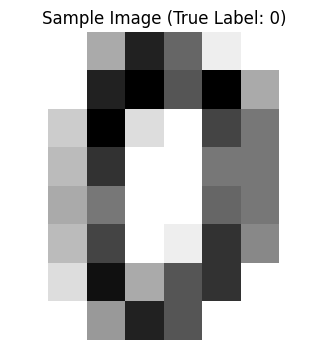

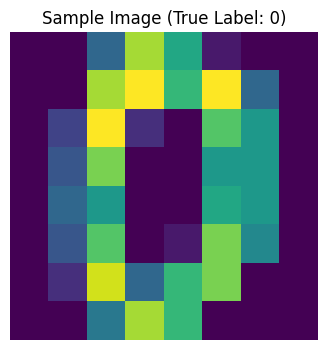


Explanation:
The MNIST dataset contains 8x8 pixel images of handwritten digits.
Each image is represented as a flattened array of 64 pixel values (8 * 8 = 64).
Each value in the array represents the intensity of a pixel, typically ranging from 0 (white) to 16 (black) in this dataset.
Clustering algorithms work with this flattened array of pixel values as the features for each image.


In [ ]:
# Reshape the image data back to its original 8x8 format for visualization
images = digits.images

# Take a single data observation (e.g., the first image)
single_image_data = X[0]
single_image_pixels = images[0] # The 8x8 pixel array

print("Shape of the single image data (flattened):", single_image_data.shape)
print("Pixel values for the first image (flattened):", single_image_data)

print("\nShape of the single image (8x8 array):", single_image_pixels.shape)
print("Pixel values for the first image (8x8 array):\n", single_image_pixels)


# Plot the single image
plt.figure(figsize=(4, 4))
plt.imshow(single_image_pixels, cmap='binary')
plt.title(f'Sample Image (True Label: {y[0]})')
plt.axis('off')
plt.show()

# Plot the single image
plt.figure(figsize=(4, 4))
plt.imshow(single_image_pixels, cmap='viridis')
plt.title(f'Sample Image (True Label: {y[0]})')
plt.axis('off')
plt.show()

print("\nExplanation:")
print("The MNIST dataset contains 8x8 pixel images of handwritten digits.")
print("Each image is represented as a flattened array of 64 pixel values (8 * 8 = 64).")
print("Each value in the array represents the intensity of a pixel, typically ranging from 0 (white) to 16 (black) in this dataset.")
print("Clustering algorithms work with this flattened array of pixel values as the features for each image.")

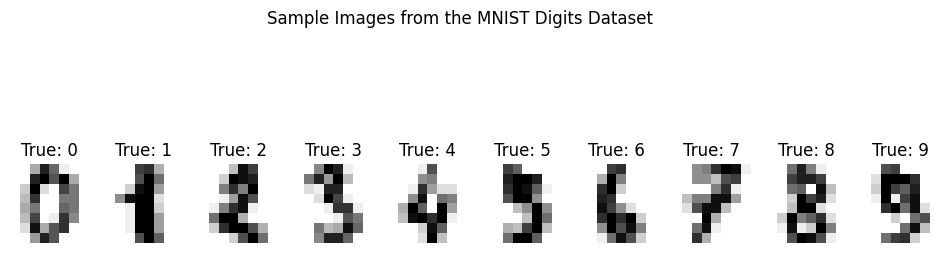

In [ ]:
# Reshape the image data back to its original 8x8 format for visualization
images = digits.images

# Display a few sample images
n_images_to_show = 10
plt.figure(figsize=(12, 4))
for i in range(n_images_to_show):
    plt.subplot(1, n_images_to_show, i + 1)
    plt.imshow(images[i], cmap='binary')
    plt.title(f'True: {y[i]}')
    plt.axis('off')
plt.suptitle("Sample Images from the MNIST Digits Dataset")
plt.show()

**Optional: Apply PCA for Dimensionality Reduction**

In [ ]:
# Clustering on the raw pixel data (64 features) can be noisy and computationally expensive.
# PCA can reduce dimensionality while retaining most of the variance.
# We'll reduce to a smaller number of components, say 30-40, which often works well for MNIST.
n_components = 40 # Let's try 40 principal components
pca = PCA(n_components=n_components, random_state=42)
X_reduced = pca.fit_transform(X)

print(f"\nShape of data after PCA ({n_components} components):", X_reduced.shape)


Shape of data after PCA (40 components): (1797, 40)


In [ ]:
X_reduced[:5]

array([[ -1.25946645, -21.27488348,   9.46305462, -13.01418869,
          7.12882278,   7.44065876,  -3.25283716,  -2.55347036,
          0.58184214,  -3.62569695,  -2.58595688,   1.55160708,
         -0.85449671,  -3.33874935,  -5.90658968,  -2.74359339,
         -0.41983691,  -0.89814969,   0.70261087,   3.46211868,
          2.68084958,   1.00944951,   2.00970276,   1.29531479,
          1.17887873,   2.30058185,   3.67072108,   0.9436689 ,
          1.13250195,  -2.3597955 ,   1.81738593,  -0.75501628,
          0.16284181,  -2.11297739,   1.09482318,  -0.19568553,
          0.08999361,  -2.76374068,   1.08888322,   0.20600401],
       [  7.9576113 ,  20.76869896,  -4.43950604,  14.89366444,
         -5.89624878,   6.48562213,  -2.12622768,   4.61593641,
         -3.58745013,   1.07470456,   5.38571495,  -2.12951093,
          2.55532447,  -6.51699585,   2.29176445,   2.13402725,
          5.83935668,   4.47844612,  -1.95570261,   5.25570801,
         -1.20577667,  -4.83890162,   0

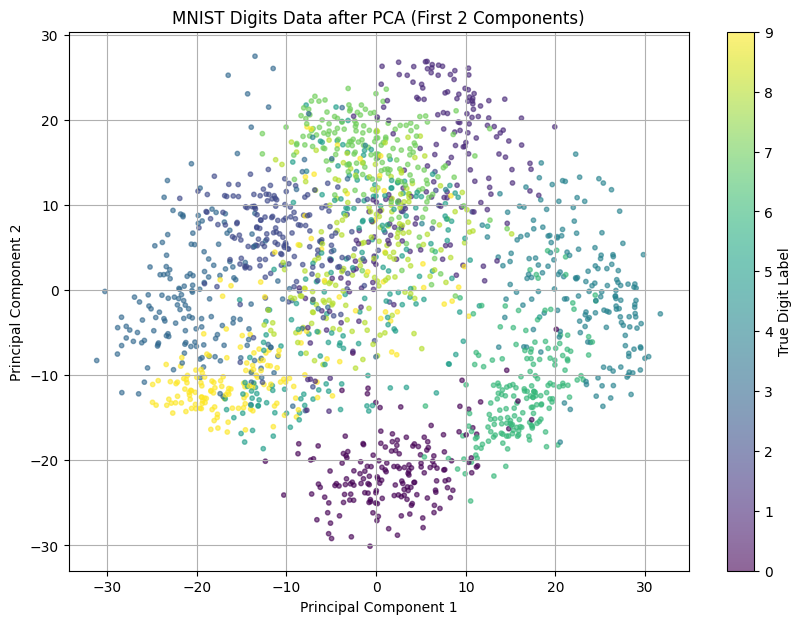

In [ ]:
# Plot the data after PCA
plt.figure(figsize=(10, 7))
# Using the true labels for color to see how well the clusters align
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='viridis', marker='o', s=10, alpha=0.6)
plt.title('MNIST Digits Data after PCA (First 2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(10), label='True Digit Label')
plt.grid(True)
plt.show()

In [ ]:
# We will perform clustering on the reduced data (X_reduced)
data_to_cluster = X_reduced
n_clusters_expected = len(np.unique(y)) # We know there are 10 digits (classes)

**2. Perform K-Means Clustering on Image Data (Reduced)**

In [ ]:
print(f"\n--- Performing K-Means Clustering with k={n_clusters_expected} ---")
kmeans_image = KMeans(n_clusters=n_clusters_expected, random_state=42, n_init='auto')
kmeans_image.fit(data_to_cluster)
kmeans_labels = kmeans_image.labels_
kmeans_centroids = kmeans_image.cluster_centers_

print("First 10 K-Means cluster assignments:", kmeans_labels[:10])
print("Shape of K-Means centroids:", kmeans_centroids.shape)


--- Performing K-Means Clustering with k=10 ---
First 10 K-Means cluster assignments: [3 2 4 8 7 8 6 5 4 8]
Shape of K-Means centroids: (10, 40)


In [ ]:
# Since the data was reduced by PCA, the centroids are in the PCA space.
# We can inverse transform them to visualize what the average image in each cluster looks like.
# However, inverse transform might not perfectly recover the original image characteristics.
# A more common visualization for K-Means on images is to show a few images from each cluster.

# Let's map the cluster labels to the true digit labels for evaluation purposes
# This helps us understand which cluster corresponds to which digit
from scipy.stats import mode

labels = np.zeros_like(kmeans_labels)
for i in range(n_clusters_expected):
    mask = (kmeans_labels == i)
    # Find the mode (most frequent) true label for points in this cluster
    labels[mask] = mode(y[mask], keepdims=False)[0]


In [ ]:
# Evaluate the clustering
from sklearn.metrics import confusion_matrix, accuracy_score

# Note: Clustering accuracy here is tricky because cluster labels don't inherently map to digit labels.
# We've done a simple mapping based on the mode of the true labels within each cluster.
# A better measure is often the adjusted Rand index or mutual information score.

print("\nK-Means Evaluation (based on mode mapping):")
# print("Confusion Matrix:\n", confusion_matrix(y, labels))
print("Accuracy (based on mode mapping):", accuracy_score(y, labels))
print("Silhouette Score:", silhouette_score(data_to_cluster, kmeans_labels))


K-Means Evaluation (based on mode mapping):
Accuracy (based on mode mapping): 0.7874234835837507
Silhouette Score: 0.19079858760998394


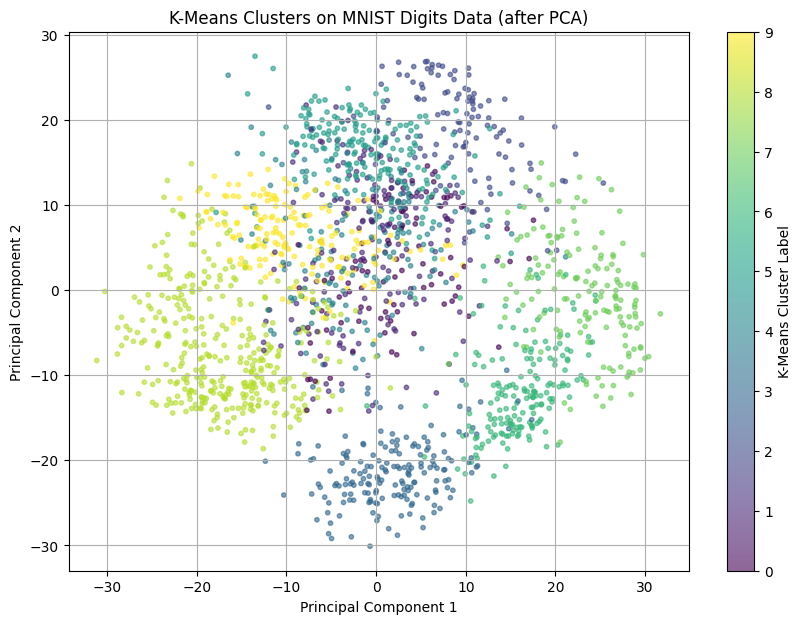

In [ ]:
plt.figure(figsize=(10, 7))
# Plot the reduced data (first 2 components) colored by K-Means cluster labels
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=kmeans_labels, cmap='viridis', marker='o', s=10, alpha=0.6)
# Plot the K-Means centroids in the reduced space (optional)
# Note: Centroids need to be transformed by PCA as well if you want to plot them in this space.
# centroids_reduced = pca.transform(kmeans_centroids_original_space) # Assuming you saved original centroids
# plt.scatter(centroids_reduced[:, 0], centroids_reduced[:, 1], c='red', marker='X', s=100, label='Centroids', edgecolor='black')

plt.title('K-Means Clusters on MNIST Digits Data (after PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(n_clusters_expected), label='K-Means Cluster Label')
plt.grid(True)
# plt.legend() # Uncomment if plotting centroids
plt.show()

In [ ]:
# Visualize some images from each K-Means cluster (optional, requires more code to select representatives)
# For simplicity, let's just visualize the distribution of true labels within clusters

**3. Perform Hierarchical Clustering on Image Data (Reduced)**

In [ ]:
print(f"\n--- Performing Hierarchical Clustering with k={n_clusters_expected} ---")

# Agglomerative clustering with a specified number of clusters
agg_image = AgglomerativeClustering(n_clusters=n_clusters_expected, linkage='ward')
agg_labels = agg_image.fit_predict(data_to_cluster)

print("First 10 Hierarchical cluster assignments:", agg_labels[:10])



--- Performing Hierarchical Clustering with k=10 ---
First 10 Hierarchical cluster assignments: [7 9 5 0 3 0 6 1 5 0]


In [ ]:
# Map the cluster labels to the true digit labels for evaluation
labels_agg = np.zeros_like(agg_labels)
for i in range(n_clusters_expected):
    mask = (agg_labels == i)
    if np.any(mask): # Ensure the cluster is not empty
        labels_agg[mask] = mode(y[mask], keepdims=False)[0]
    else:
         labels_agg[mask] = -1 # Mark empty clusters

In [ ]:
# Evaluate the clustering
print("\nHierarchical Clustering Evaluation (based on mode mapping):")
# print("Confusion Matrix:\n", confusion_matrix(y, labels_agg))
print("Accuracy (based on mode mapping):", accuracy_score(y, labels_agg))
print("Silhouette Score:", silhouette_score(data_to_cluster, agg_labels))



Hierarchical Clustering Evaluation (based on mode mapping):
Accuracy (based on mode mapping): 0.8391764051196439
Silhouette Score: 0.18225805930856595


**Optional: Visualize Dendrogram (on a subset of data for performance)**


--- Visualizing Dendrogram (on a subset of data) ---


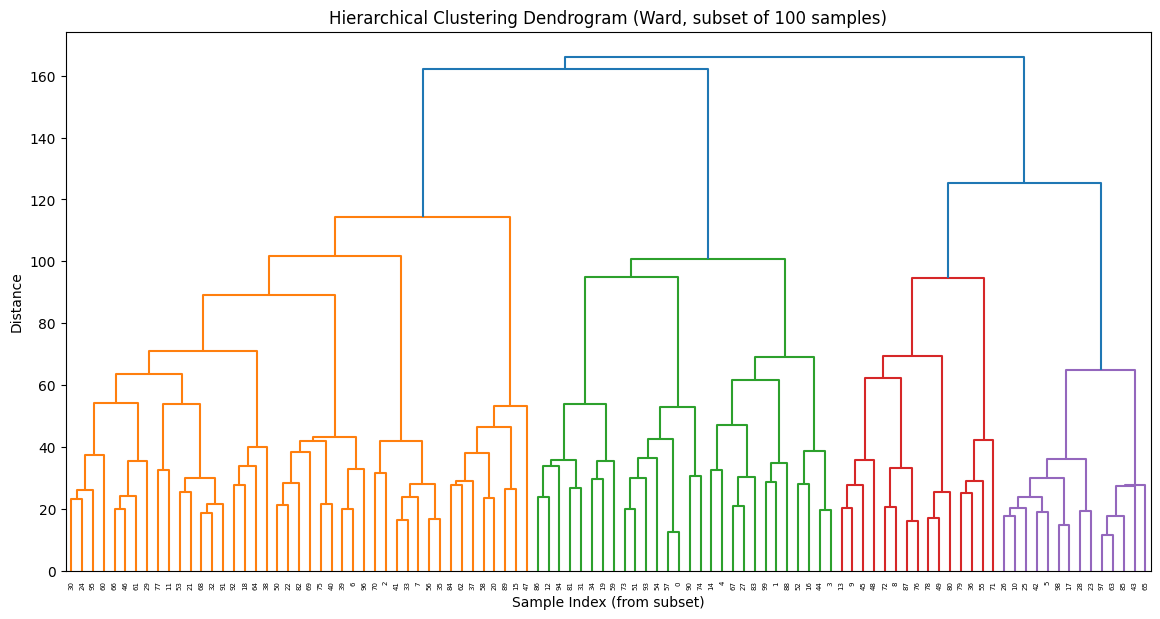

Dendrogram shows hierarchical structure for a random subset of 100 samples.
To see clusters, you'd typically cut the dendrogram horizontally.


In [ ]:
print("\n--- Visualizing Dendrogram (on a subset of data) ---")
n_subset = 100 # Use a smaller subset for faster computation and clearer visualization
subset_indices = np.random.choice(len(data_to_cluster), n_subset, replace=False)
X_subset = data_to_cluster[subset_indices]
y_subset = y[subset_indices]

linked_subset = linkage(X_subset, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linked_subset,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           # Add color threshold to highlight clusters at a certain distance
           # color_threshold=None # Set a value based on where you'd cut for k=10
           )
plt.title(f'Hierarchical Clustering Dendrogram (Ward, subset of {n_subset} samples)')
plt.xlabel(f'Sample Index (from subset)')
plt.ylabel('Distance')
plt.show()
print(f"Dendrogram shows hierarchical structure for a random subset of {n_subset} samples.")
print("To see clusters, you'd typically cut the dendrogram horizontally.")

**Conclusion**

In [ ]:
print("\nClustering on the MNIST digits dataset:")
print(f"K-Means (k={n_clusters_expected}) Accuracy: {accuracy_score(y, labels):.3f}, Silhouette: {silhouette_score(data_to_cluster, kmeans_labels):.3f}")
print(f"Hierarchical (k={n_clusters_expected}) Accuracy: {accuracy_score(y, labels_agg):.3f}, Silhouette: {silhouette_score(data_to_cluster, agg_labels):.3f}")

print("\nNote: Accuracy here is based on mapping clusters to true labels using the mode.")
print("Clustering is unsupervised; the goal is to find groups, not necessarily recover original labels perfectly.")
print("The silhouette score gives an idea of how well-separated the clusters are.")
print("PCA was used to reduce dimensionality before clustering, which is common practice for image data.")
print("Visualizing the dendrogram helps understand the hierarchy of clusters.")


Clustering on the MNIST digits dataset:
K-Means (k=10) Accuracy: 0.787, Silhouette: 0.191
Hierarchical (k=10) Accuracy: 0.839, Silhouette: 0.182

Note: Accuracy here is based on mapping clusters to true labels using the mode.
Clustering is unsupervised; the goal is to find groups, not necessarily recover original labels perfectly.
The silhouette score gives an idea of how well-separated the clusters are.
PCA was used to reduce dimensionality before clustering, which is common practice for image data.
Visualizing the dendrogram helps understand the hierarchy of clusters.
